Explanation:
Import libraries required for modeling and evaluation.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
# load data 
train_df = pd.read_csv(r"C:/Users/daraa/Desktop/Transformer-based vs. Hybrid Deep Learning Architectures/Data/train.csv")
train_df['date'] = pd.to_datetime(train_df['date'])

In [3]:
# Recreate features 
train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day'] = train_df['date'].dt.day
train_df['day_of_week'] = train_df['date'].dt.weekday
train_df['week_of_year'] = train_df['date'].dt.isocalendar().week

In [4]:
# Lag features
train_df['lag_7'] = train_df['sales'].shift(7)
train_df['lag_14'] = train_df['sales'].shift(14)
train_df['lag_30'] = train_df['sales'].shift(30)

In [5]:
train_df[['sales','lag_7','lag_14','lag_30']].head(15)

,sales,lag_7,lag_14,lag_30
0,13,NaN,NaN,NaN
1,11,NaN,NaN,NaN
2,14,NaN,NaN,NaN
3,13,NaN,NaN,NaN
4,10,NaN,NaN,NaN
5,12,NaN,NaN,NaN
6,10,NaN,NaN,NaN
7,9,13.0,NaN,NaN
8,12,11.0,NaN,NaN
9,9,14.0,NaN,NaN


In [6]:
# Rolling Statistics
train_df['rolling_mean_7'] = train_df['sales'].rolling(7).mean()
train_df['rolling_std_7'] = train_df['sales'].rolling(7).std()

In [7]:
# Removing missing values (Lag Created NaN Values Before)
train_df = train_df.dropna()
train_df.shape

(912970, 14)

In [8]:
train_df[['sales','lag_7','lag_14','lag_30']].head(15)

,sales,lag_7,lag_14,lag_30
30,13,8.0,16.0,13.0
31,11,14.0,7.0,11.0
32,21,12.0,18.0,14.0
33,15,12.0,15.0,13.0
34,14,11.0,8.0,10.0
35,9,6.0,7.0,12.0
36,10,9.0,9.0,10.0
37,13,13.0,8.0,9.0
38,11,11.0,14.0,12.0
39,14,21.0,12.0,9.0


In [9]:
# Select features and Target
features = [
'store','item','year','month','day',
'day_of_week','week_of_year',
'lag_7','lag_14','lag_30',
'rolling_mean_7','rolling_std_7'
]

X = train_df[features]
y = train_df['sales']

In [10]:
print(X.shape)
print(y.shape)

(912970, 12)
(912970,)


In [11]:
# Train Validation Split(Time-Series)
split = int(len(X) * 0.8)

X_train = X[:split]
X_val = X[split:]

y_train = y[:split]
y_val = y[split:]

In [12]:
# Linear Regression Model
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_val)

In [18]:
# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

from sklearn.metrics import mean_squared_error
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 6.085132147718738


In [14]:
# Evaluate Models
rmse_lr = np.sqrt(mean_squared_error(y_val, lr_pred))
rmse_rf = np.sqrt(mean_squared_error(y_val, rf_pred))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 7.062849046138271
Random Forest RMSE: 6.085132147718738


In [16]:
# MAE
mae_lr = mean_absolute_error(y_val, lr_pred)
mae_rf = mean_absolute_error(y_val, rf_pred)

print("Linear Regression MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)

Linear Regression MAE: 5.484151343591604
Random Forest MAE: 4.67843028796127


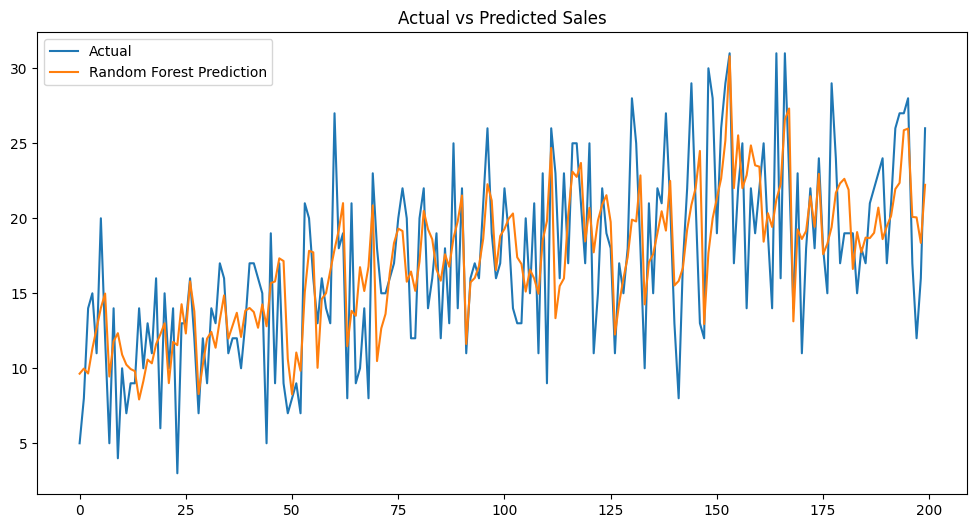

In [22]:
# Visualization (Actual Vs Predicted)
plt.figure(figsize=(12,6))

plt.plot(y_val.values[:200], label="Actual")
plt.plot(rf_pred[:200], label="Random Forest Prediction")

plt.legend()
plt.title("Actual vs Predicted Sales")

plt.savefig("model_comparison(Actual Vs Predicted).png")
plt.show()